# 3.1. Predictive Modelling

The purpose of this notebook is to determine which among the SVC, Tree classifier, and logistic regression yield the highest test score given a chosen metric. 

In [1]:
%load_ext autoreload
%autoreload 2

# Standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

**TASK 1.** Load the data and create the features matrix and target matrix

In [2]:
# Load data
from pathlib import Path

file = Path.cwd().parent / 'data/processed/api-launch-data-table-class.csv'
data = pd.read_csv(file)
data.dtypes

launch_designator        str
booster_version          str
orbit                    str
launch_site              str
flights                int64
reused                  bool
landing_pad              str
block                    str
serial                   str
longitude            float64
latitude             float64
reused_count           int64
outcome                  str
OrbPay               float64
launch_date              str
gridfins                bool
legs                    bool
class                  int64
dtype: object

In [3]:
cat_cols = ['orbit', 'launch_site', 'reused', 'block', 'gridfins', 'legs']
con_cols = ['OrbPay', 'flights', 'reused_count']
target_col = 'class'

cats = [data[col].unique() for col in cat_cols]

X = pd.concat([data[cat_cols],data[con_cols]], axis=1).to_numpy()
y = data[target_col].to_numpy()
X.shape, y.shape

((95, 9), (95,))

**TASK 2.** Instantiate components of the preprocessor -- `OneHotEncoder` and `StandardScaler`

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

build_features = ColumnTransformer([
    ('encode', OneHotEncoder(sparse_output=False, dtype=int, categories=cats), list(range(0,6))),
    ('scale', StandardScaler(), list(range(6,9)))
])

**TASK 3.** Split the data into training and test sets with `test_size = 0.2` and `random_state = 2`.

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2, stratify=y)

In [6]:
X_train.shape, X_test.shape

((76, 9), (19, 9))

**TASK 4. (Logistic Regression)** Create a pipeline with `build_features` as the preprocessor, and Logistic Regression as the estimator. Do a grid search with the pipeline, considering `C`, `penalty`, and `solver` in the hyperparameter grid.

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

logreg_param_grid = {
    'estimator__C': [0.01, 0.1, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5],
    'estimator__l1_ratio': [0],
    'estimator__solver': ['lbfgs']
}
logreg = Pipeline([('transformer', build_features),
                   ('estimator', LogisticRegression())
                  ])

logreg_gridcv = GridSearchCV(logreg, logreg_param_grid)
logreg_gridcv.fit(X_train, y_train)

print("best parameters: {}".format(logreg_gridcv.best_params_))
print("accuracy: {}".format(logreg_gridcv.best_score_))

best parameters: {'estimator__C': 1.0, 'estimator__l1_ratio': 0, 'estimator__solver': 'lbfgs'}
accuracy: 0.9216666666666666


**TASK 5. (Logistic Regression Evaluation)** Calculate the score of the logistic regression pipeline on the test set and plot the confusion matrix.

In [8]:
logreg_score = logreg_gridcv.score(X_test, y_test)
print('Logistic Regression Score: {}'.format(logreg_score))

Logistic Regression Score: 0.8421052631578947


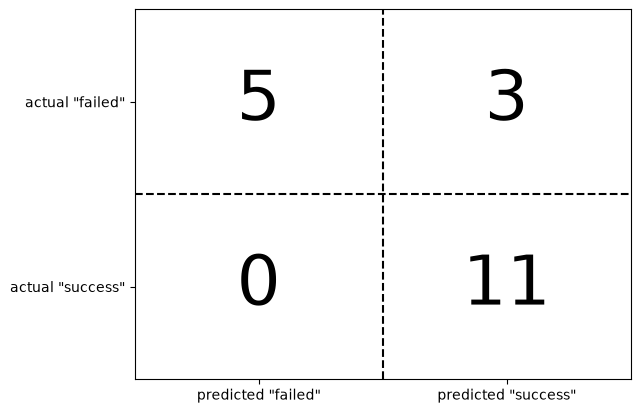

In [9]:
from sklearn.metrics import confusion_matrix

def binary_confusion_plot(binary_confusion_matrix, positive_class, negative_class, ax=None):
    if ax is None:
        ax = plt.gca()
    
    for i in range(binary_confusion_matrix.shape[0]):
        for j in range(binary_confusion_matrix.shape[1]):
            ax.text(j, i, '{}'.format(binary_confusion_matrix[::-1][i,j]),
                   ha='center', va='center', fontsize=50)
    
    ax.vlines(x=0.5, ymin=-0.5, ymax=1.5, linestyle='--', colors='k')
    ax.plot([-0.5,1.5], [0.5,0.5], linestyle='--', c='k')
    ax.set_xticks([0,1], labels=[f'predicted "{negative_class}"', f'predicted "{positive_class}"'])
    ax.set_xlim(-0.5,1.5)
    ax.set_yticks([0,1], labels=[f'actual "{positive_class}"', f'actual "{negative_class}"'])
    ax.set_ylim(-0.5,1.5)

logreg_predict = logreg_gridcv.predict(X_test)
logreg_confusion = confusion_matrix(y_test, logreg_predict)
binary_confusion_plot(logreg_confusion, 'success', 'failed')

**Conclusion.** what...

**TASK 6. (Support Vector Classifier)** Create a pipeline with `build_features` as the preprocessor, and Support Vector Classifoer as the estimator. Do a grid search with the pipeline, considering `C`, `gamma`, and `kernel` in the hyperparameter grid.

In [10]:
from sklearn.svm import SVC

svc_param_grid = [
    {
        'estimator__kernel':['poly', 'rbf', 'sigmoid'],
        'estimator__C': np.logspace(-3, 3, 5),
        'estimator__gamma':np.logspace(-3, 3, 5)
    },
    {
        'estimator__kernel':['linear',],
        'estimator__C': np.logspace(-3, 3, 5)
    }
]

svc = Pipeline([
    ('transformer', build_features),
    ('estimator', SVC())
])

svc_gridcv = GridSearchCV(svc, svc_param_grid)
svc_gridcv.fit(X_train,y_train)

print("best parameters: {}".format(svc_gridcv.best_params_))
print("accuracy: {}".format(svc_gridcv.best_score_))

best parameters: {'estimator__C': np.float64(1000.0), 'estimator__kernel': 'linear'}
accuracy: 0.9341666666666667


In [11]:
def heat_map_2D(grid_cv_results, param_grid, param_1, param_2, ax=None):
    if ax is None:
        ax = plt.gca()

    #Get mean test score and reshape results
    shape_1 = len(param_grid[param_1])
    shape_2 = len(param_grid[param_2])
    results = grid_cv_results['mean_test_score'].to_numpy().reshape(shape_1,shape_2)[::-1,::]

    im = ax.imshow(results)
    
    ax.set_xticks(range(shape_1), labels=['{:.3f}'.format(p) for p in param_grid[param_1]])
    ax.set_yticks(range(shape_2), labels=['{:.3f}'.format(p) for p in param_grid[param_2][::-1]])
    
    for i in range(shape_1):
        for j in range(shape_2):
            text = ax.text(j, i, '{:.3f}'.format(results[i,j]),
                          ha='center', va='center', color='w')
    
    ax.set_title('Heat map of mean cross-validation score')
    ax.set_xlabel(param_1)
    ax.set_ylabel(param_2)
    plt.colorbar(im)

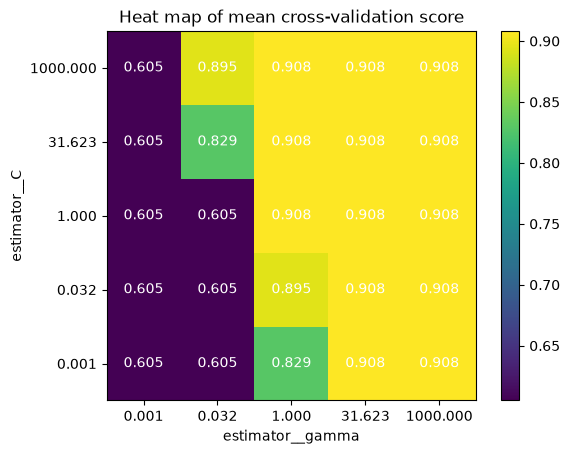

In [12]:
df_grid = pd.DataFrame(svc_gridcv.cv_results_)
grid_cv_results = df_grid[df_grid['param_estimator__kernel']=='poly']
param_1 = 'estimator__gamma'
param_2 = 'estimator__C'

heat_map_2D(grid_cv_results, svc_param_grid[0], param_1, param_2)

**TASK 7. (Support Vector Classifier Evaluation)** Evaluate the results of the SVC grid. Determine the test score and plot the confusion matrix.

In [13]:
svc_score = svc_gridcv.score(X_test,y_test)
svc_pred = svc_gridcv.best_estimator_.predict(X_test)
svc_confusion = confusion_matrix(y_test, svc_pred)

print('SVC Score: {:.3f}'.format(svc_score))

SVC Score: 0.895


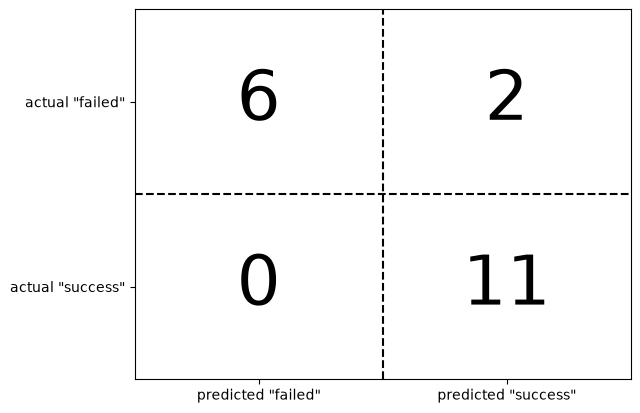

In [14]:
binary_confusion_plot(svc_confusion, 'success', 'failed')

**TASK 8. (Decision Tree Classifier)** Create a pipeline with `build_features` as the preprocessor, and Decision Tree Classifier as the estimator. Do a grid search with the pipeline, considering `criterion`, `splitter`, `max_depth`, `max_features`, `min_samples_leaf`, and `min_samples_split` in the hyperparameter grid.

In [15]:
from sklearn.tree import DecisionTreeClassifier

tree_param_grid = {'estimator__criterion': ['gini', 'entropy'],
     'estimator__splitter': ['best', 'random'],
     'estimator__max_depth': [2*n for n in range(1,10)],
     'estimator__max_features': ['log2', 'sqrt'],
     'estimator__min_samples_leaf': [1, 2, 4],
     'estimator__min_samples_split': [2, 5, 10]}

tree = Pipeline([
    ('transformer', build_features),
    ('estimator', DecisionTreeClassifier())
])

tree_gridcv = GridSearchCV(tree, tree_param_grid)
tree_gridcv.fit(X_train, y_train)

print("best parameters: {}".format(tree_gridcv.best_params_))
print("accuracy: {}".format(tree_gridcv.best_score_))

best parameters: {'estimator__criterion': 'entropy', 'estimator__max_depth': 14, 'estimator__max_features': 'log2', 'estimator__min_samples_leaf': 4, 'estimator__min_samples_split': 5, 'estimator__splitter': 'random'}
accuracy: 0.9349999999999999


**TASK 9. (Decision Tree Classifier Evaluation)** Evaluate the grid search with the decision tree classifier. Determine the test score and plot the confusion matrix.

In [16]:
tree_score = tree_gridcv.score(X_test, y_test)
print('Decision Tree Classifier Score: {:.3f}'.format(tree_score))

Decision Tree Classifier Score: 0.842


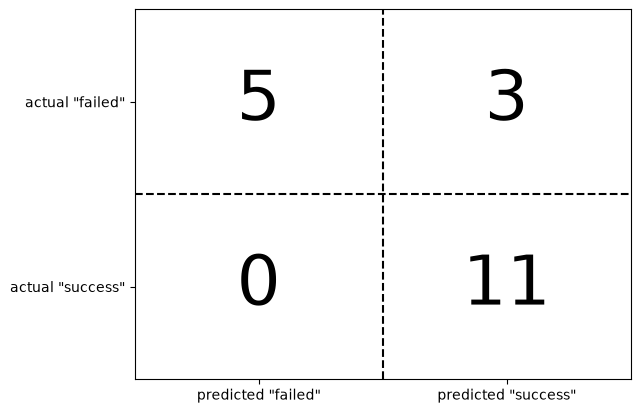

In [17]:
tree_pred = tree_gridcv.predict(X_test)
tree_confusion = confusion_matrix(y_test, tree_pred)

binary_confusion_plot(tree_confusion, 'success', 'failed')

**TASK 10. (K Neighbors Classifier)** Create a pipeline with `build_features` as the preprocessor, and K Neighbors Classifier as the estimator. Do a grid search with the pipeline, considering `n_neighbors`, `algorithm`, and `p` in the hyperparameter grid.

In [18]:
from sklearn.neighbors import KNeighborsClassifier

knn_param_grid = {'estimator__n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
              'estimator__algorithm': ['ball_tree', 'kd_tree', 'brute'],
              'estimator__p': [1,2]}

knn = Pipeline([
    ('transformer', build_features),
    ('estimator', KNeighborsClassifier())
])

knn_gridcv = GridSearchCV(knn, knn_param_grid)
knn_gridcv.fit(X_train, y_train)

print('best parameters: {}'.format(knn_gridcv.best_params_))
print('best score: {}'.format(knn_gridcv.best_score_))

best parameters: {'estimator__algorithm': 'ball_tree', 'estimator__n_neighbors': 10, 'estimator__p': 1}
best score: 0.8958333333333333


**TASK 11. (K Neighbors Classifier Evaluation)** Evaluate the grid search with K-Neighbors Classifier. Determine the test score and plot the confusion matrix.

In [19]:
knn_score = knn_gridcv.score(X_test, y_test)
print('K Neighbors Classifier Score: {:.3f}'.format(knn_score))

K Neighbors Classifier Score: 0.737


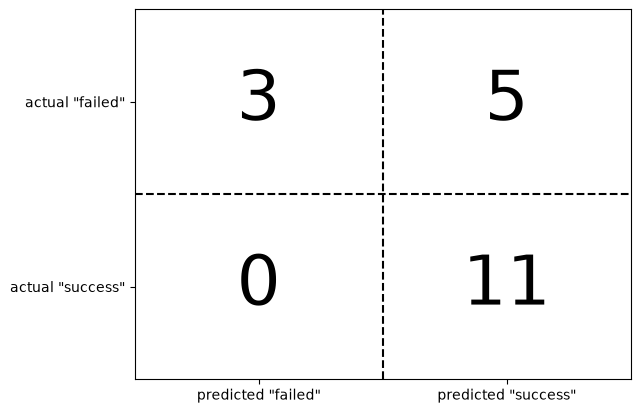

In [20]:
knn_pred = knn_gridcv.predict(X_test)
knn_confusion = confusion_matrix(y_test, knn_pred)

binary_confusion_plot(knn_confusion, 'success', 'failed')

**TASK 12** Determine which method is the best

In [21]:
models_results = {
    'classifiers': ['Logistic Regression', 'Support Vector Classifier', 'Decision Tree Classifier', 'K Neighbors Classifier'],
    'best_cross_val_score': [logreg_gridcv.best_score_, svc_gridcv.best_score_, tree_gridcv.best_score_, knn_gridcv.best_score_],
    'test_score': [logreg_score, svc_score, tree_score, knn_score]
}

models_df = pd.DataFrame(models_results)
print(models_df)

                 classifiers  best_cross_val_score  test_score
0        Logistic Regression              0.921667    0.842105
1  Support Vector Classifier              0.934167    0.894737
2   Decision Tree Classifier              0.935000    0.842105
3     K Neighbors Classifier              0.895833    0.736842


The best method to use is the Support Vector Classifier, getting the highest test score of 89%.

# Rev01

In [22]:
from spacey_falcon_9_project.features import build_features, load_training_set, load_test_set
from spacey_falcon_9_project.config import random_state, training_set, test_set, processed_dir

In [23]:
X_train, y_train = load_training_set()
X_test, y_test = load_test_set()

In [24]:
transformer = build_features()

In [25]:
transformer

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('regroup_encode', ...), ('encode', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` a

## Baseline - Dummy Classifier

In [26]:
from sklearn.compose import ColumnTransformer

simple_transformer = ColumnTransformer(
    [
        (
            'scale', 
            StandardScaler(), 
            [
                'payload_mass',
                'reused_count',
                'nearest_highway',
                'nearest_railway',
                'nearest_coastline'
            ]
        ),
        (
            'encode', 
            OneHotEncoder(sparse_output=False, dtype=int), 
            [
                'orbit', 
                'mission_type', 
                'block'
            ]
        )
    ],
    remainder='drop'
)

In [27]:
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import make_pipeline

dummy1 = make_pipeline(simple_transformer, DummyClassifier(strategy='most_frequent'))
dummy1.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columntransformer', ...), ('dummyclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](20,)","['launch_designator','booster_version','orbit',...,'nearest_highway', 'nearest_railway','nearest_coastline']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,20
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scale', ...), ('encode', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``

In [28]:
from sklearn.pipeline import Pipeline

dummy = Pipeline([
    ("transformer", transformer),
    ("classifier", DummyClassifier(strategy="most_frequent"))
])

dummy.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('transformer', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](20,)","['launch_designator','booster_version','orbit',...,'nearest_highway', 'nearest_railway','nearest_coastline']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,20
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('regroup_encode', ...), ('encode', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of

In [29]:
print("Dummy w/ build_features: {: .2%}".format(dummy.score(X_test, y_test)))
print("Dummy w/ simple_transformer: {: .2%}".format(dummy1.score(X_test, y_test)))

Dummy w/ build_features:  91.89%
Dummy w/ simple_transformer:  91.89%


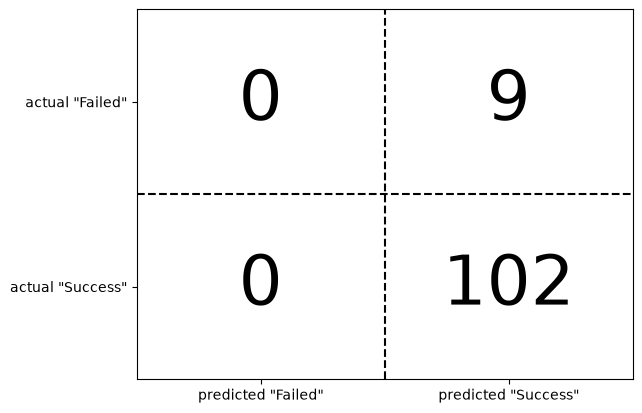

In [30]:
dummy_confusion = confusion_matrix(y_test, dummy.predict(X_test))
binary_confusion_plot(dummy_confusion, positive_class="Success", negative_class="Failed")

In [31]:
from sklearn.metrics import classification_report

print(classification_report(y_test, dummy.predict(X_test), zero_division=0))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         9
           1       0.92      1.00      0.96       102

    accuracy                           0.92       111
   macro avg       0.46      0.50      0.48       111
weighted avg       0.84      0.92      0.88       111



## Metric

Assume that a false positive is ten times more costlier than a false negative. With that, for each false positive, the model will gain `-10`, and `-1` for each false negative. The total gain will then be considered as the metric for tuning the threshold and evaluating model performance on the test set.

$$\text{score} = (-10)\cdot \text{FP} + (-1)\cdot \text{FN}$$

In [32]:
def gain_score(y, y_pred, **kwargs):

    weight_fp = kwargs.get('weight_fp', 10)
    weight_fn = kwargs.get('weight_fn', 1)
    
    cm = confusion_matrix(y,y_pred)
    gm = np.array(
        [
            [0, -weight_fp],
            [-weight_fn, 0]
        ]
    )

    return np.sum(cm * gm)

## Model Selection

### Logistic Regression

In [33]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import TunedThresholdClassifierCV
from sklearn.metrics import average_precision_score
from scipy.stats import loguniform, uniform

lr_param_grid = {
    'classifier__C': uniform(loc=0.05, scale=0.15),
    'classifier__l1_ratio': uniform(loc=0.01, scale=0.05),
}

lr = Pipeline([
    ('transformer', transformer),
    ('classifier', LogisticRegression(random_state=random_state, solver='saga', max_iter=50000, class_weight="balanced"))
])

lr_model = RandomizedSearchCV(lr, 
                              lr_param_grid,
                              scoring='average_precision',
                              cv=5,
                              random_state=random_state, 
                              n_iter=80,
                              n_jobs=-1)

lr_model.fit(X_train,y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...ver='saga'))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__C': <scipy.stats....t 0x30f3e7e00>, 'classifier__l1_ratio': <scipy.stats....t 0x30fa5d090>}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",80
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metri

#### Results

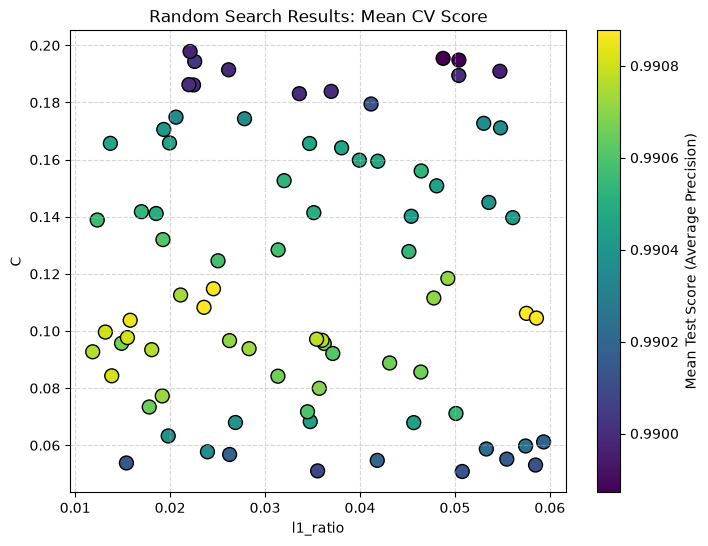

In [34]:
import matplotlib.pyplot as plt
import numpy as np

lr_cv_results = pd.DataFrame(lr_model.cv_results_)

# Extract hyperparameters and scores from cv_results_
c_vals = lr_cv_results['param_classifier__C'].astype(float)
l1_vals = lr_cv_results['param_classifier__l1_ratio'].astype(float)
scores = lr_cv_results['mean_test_score']

fig, ax = plt.subplots(figsize=(8, 6))

# Scatter plot: x=l1_ratio, y=C, color=mean_test_score
sc = ax.scatter(l1_vals, c_vals, c=scores, cmap='viridis', s=100, edgecolors='k')

ax.set_xlabel('l1_ratio')
ax.set_ylabel('C')
ax.set_title('Random Search Results: Mean CV Score')

# Add colorbar
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Mean Test Score (Average Precision)')

plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

In [35]:
results = (
    "CV Results\n"
    " Best Parameters:\n"
    "  C: {:.3f}\n"
    "  l1_ratio: {:.3f}\n"
    " Best Validation Score: {:.3%}"
).format(lr_model.best_params_['classifier__C'], lr_model.best_params_['classifier__l1_ratio'], lr_model.best_score_)

print(results)

CV Results
 Best Parameters:
  C: 0.106
  l1_ratio: 0.058
 Best Validation Score: 99.088%


### Support Vector Classifier

In [36]:
from sklearn.svm import SVC

svc_C_dist = loguniform(1e-3, 1e3)
svc_gamma_dist = loguniform(1e-4, 1e1)

svc_param_grid = [
    {
        'classifier__kernel': ['linear'],
        'classifier__C': svc_C_dist,
    },
    {
        'classifier__kernel': ['rbf', 'sigmoid'],
        'classifier__C': svc_C_dist,
        'classifier__gamma': svc_gamma_dist
    },
    {
        'classifier__kernel': ['poly'],
        'classifier__C': svc_C_dist,
        'classifier__gamma': svc_gamma_dist,
        'classifier__degree': [2,3,5,7]
    }
]

svc_model = RandomizedSearchCV(
    Pipeline([('transformer', transformer),
              ('classifier', SVC(class_weight='balanced', random_state=random_state, verbose=1))
             ]),
    svc_param_grid,
    scoring = 'average_precision',
    cv = 5,
    random_state = random_state,
    n_iter = 80,
    verbose = 3,
    n_jobs = -1
)

svc_model.fit(X_train, y_train)

Fitting 5 folds for each of 80 candidates, totalling 400 fits
.............................*................................................*...................................*..........*...*.....*
optimization finished, #iter = 18251
.obj = -1737.467297, rho = 14.949327
nSV = 66, nBSV = 25
Total nSV = 66
.................................................................*
optimization finished, #iter = 50517
obj = -1389.169026, rho = 13.923948
nSV = 67, nBSV = 23
Total nSV = 67
...............................*......................................................*
optimization finished, #iter = 30070
obj = -865.207467, rho = 13.185368
nSV = 52, nBSV = 11
Total nSV = 52
............................*.....*
optimization finished, #iter = 11940
obj = -1467.746923, rho = 24.888936
nSV = 55, nBSV = 22
Total nSV = 55
..................*........*
optimization finished, #iter = 312
.obj = -395.130661, rho = -0.666859
nSV = 126, nBSV = 91
Total nSV = 126
*
optimization finished, #iter = 9883
obj

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step... verbose=1))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","[{'classifier__C': <scipy.stats....t 0x3a4da9e50>, 'classifier__kernel': ['linear']}, {'classifier__C': <scipy.stats....t 0x3a4da9e50>, 'classifier__gamma': <scipy.stats....t 0x30fa16d70>, 'classifier__kernel': ['rbf', 'sigmoid']}, ...]"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",80
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",3
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there a

In [37]:
svc_model

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step... verbose=1))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","[{'classifier__C': <scipy.stats....t 0x3a4da9e50>, 'classifier__kernel': ['linear']}, {'classifier__C': <scipy.stats....t 0x3a4da9e50>, 'classifier__gamma': <scipy.stats....t 0x30fa16d70>, 'classifier__kernel': ['rbf', 'sigmoid']}, ...]"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",80
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",3
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there a

#### Initial Results

In [38]:
results = (
    "CV Results\n"
    " Best Parameters:\n"
    "  kernel: {}\n"
    "  C: {:.3f}\n"
    "  gamma: {:.3f}\n"
    " Best Validation Score: {:.3%}"
).format(svc_model.best_params_['classifier__kernel'],
         svc_model.best_params_['classifier__C'],
         svc_model.best_params_['classifier__gamma'], 
         svc_model.best_score_)

print(results)

CV Results
 Best Parameters:
  kernel: rbf
  C: 199.380
  gamma: 0.004
 Best Validation Score: 99.199%


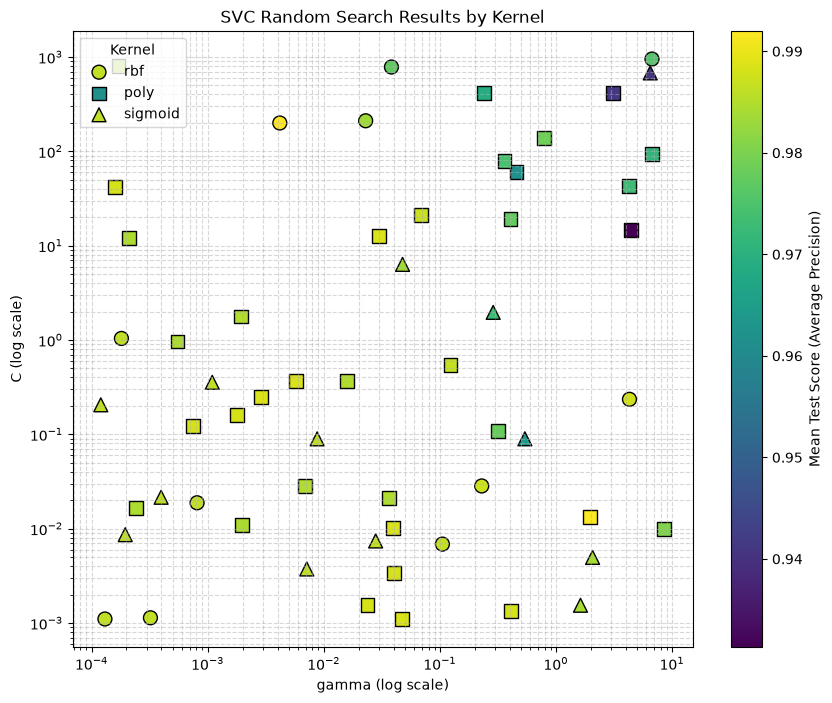

In [39]:
# Load cv_results_ into DataFrame
svc_cv_results = pd.DataFrame(svc_model.cv_results_)

fig, ax = plt.subplots(figsize=(10, 8))

def plot_svc_results_nonlinear(svc_cv_results: pd.DataFrame, ax=None):
    if not ax:
        ax = plt.gca()
    # Define markers for each kernel type
    kernel_markers = {
        'rbf': 'o',      # Circle
        'poly': 's',     # Square
        'sigmoid': '^',  # Triangle
    }
    
    # Determine global min/max scores so colorbar scale stays consistent
    vmin = svc_cv_results['mean_test_score'].min()
    vmax = svc_cv_results['mean_test_score'].max()
    
    sc = None
    for kernel_name, marker in kernel_markers.items():
        subset = svc_cv_results[svc_cv_results['param_classifier__kernel'] == kernel_name].copy()
        if subset.empty:
            continue
        
        # Extract coordinates; fill NaN for linear kernel gamma with a placeholder if needed
        c_vals = subset['param_classifier__C'].astype(float)
        gamma_vals = subset['param_classifier__gamma'].astype(float)
        scores = subset['mean_test_score']
        
        sc = ax.scatter(
            gamma_vals, 
            c_vals, 
            c=scores, 
            cmap='viridis', 
            marker=marker, 
            s=100, 
            edgecolors='k', 
            vmin=vmin, 
            vmax=vmax, 
            label=kernel_name
        )
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('gamma (log scale)')
    ax.set_ylabel('C (log scale)')
    ax.set_title('SVC Random Search Results by Kernel')
    
    # Add legend for kernel markers
    ax.legend(title="Kernel", loc="upper left")
    
    # Add colorbar for mean test scores
    if sc is not None:
        cbar = plt.colorbar(sc, ax=ax)
        cbar.set_label('Mean Test Score (Average Precision)')
    
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.show()

plot_svc_results_nonlinear(svc_cv_results, ax=ax)

high average precision scores can be observed at `gamma` values between `1e-3` to `1e-1` and `C` values between `1e1` and `1e3`, and these scores are from instances with either `poly` or `rbf` as kernels. However, one instance can be observed way outside this range but got a similarly high score with a gamma value between `1e0` and `1e1`, and a C value between `1e-2` and `1e-1`.

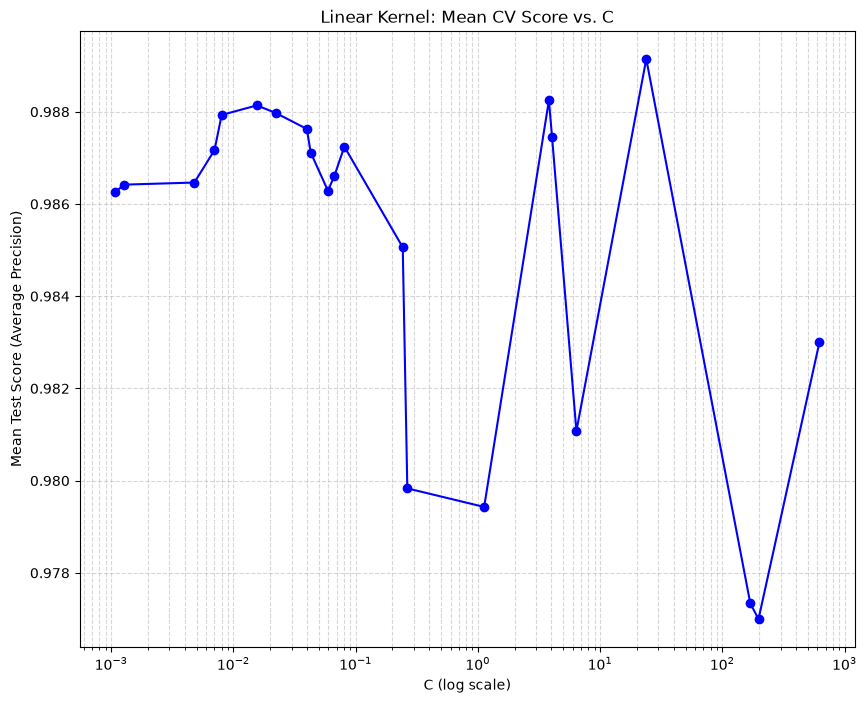

In [40]:
def plot_svc_results_linear(svc_cv_results: pd.DataFrame, ax=None):
    if not ax:
        ax = plt.gca()
    linear_subset = svc_cv_results[svc_cv_results['param_classifier__kernel'] == "linear"]
    
    # Convert C values to float and sort by C for a clean line plot
    linear_subset['C'] = linear_subset['param_classifier__C'].astype(float)
    linear_subset = linear_subset.sort_values('C')
    
    ax.plot(linear_subset['C'], linear_subset['mean_test_score'], marker='o', linestyle='-', color='b')
    ax.set_xscale('log')
    ax.set_xlabel('C (log scale)')
    ax.set_ylabel('Mean Test Score (Average Precision)')
    ax.set_title('Linear Kernel: Mean CV Score vs. C')
    ax.grid(True, which="both", ls="--", alpha=0.5)
    
    plt.show()

fig,ax = plt.subplots(figsize=(10,8))
plot_svc_results_linear(svc_cv_results, ax=ax)

Among instances that use the `linear` kernel, high scores are between `1e1` and `1e2`.

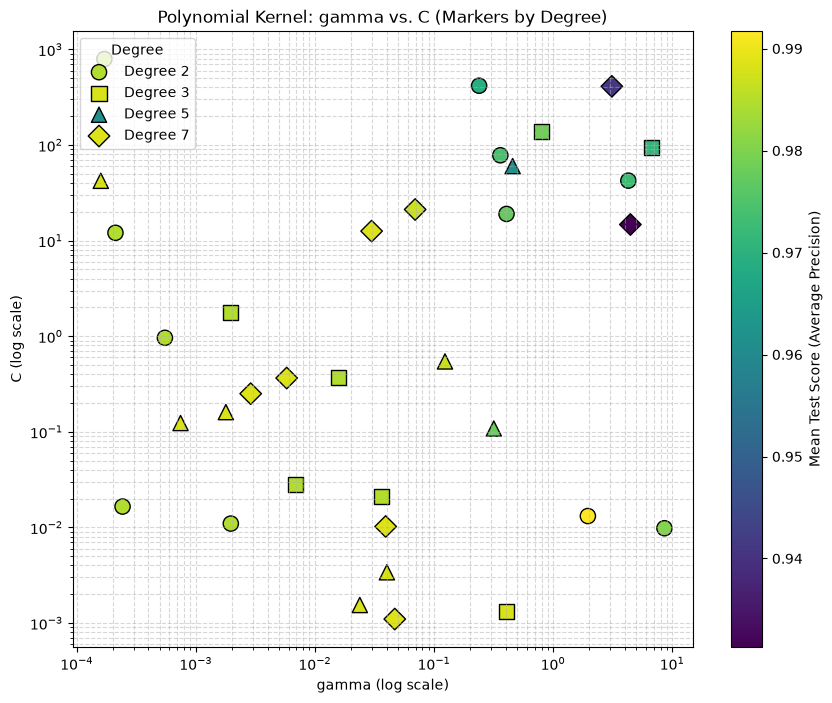

In [41]:
def plot_svc_results_poly(svc_cv_results: pd.DataFrame, ax=None):
    if not ax:
        ax = plt.gca()

    # Filter exclusively for polynomial kernel
    poly_subset = svc_cv_results[svc_cv_results['param_classifier__kernel'] == 'poly'].copy()
    
    # Ensure correct data types
    poly_subset['C'] = poly_subset['param_classifier__C'].astype(float)
    poly_subset['gamma'] = poly_subset['param_classifier__gamma'].astype(float)
    poly_subset['degree'] = poly_subset['param_classifier__degree'].astype(int)
    poly_subset['score'] = poly_subset['mean_test_score'].astype(float)
    
    # Map each unique degree to a distinct marker shape
    degree_markers = {
        2: 'o',  # Circle
        3: 's',  # Square
        5: '^',  # Triangle
        7: 'D'   # Diamond
    }
    
    # Fix color scale boundaries across all sub-plots
    vmin = poly_subset['score'].min()
    vmax = poly_subset['score'].max()
    
    sc = None
    for deg, marker in degree_markers.items():
        deg_data = poly_subset[poly_subset['degree'] == deg]
        if deg_data.empty:
            continue
            
        sc = ax.scatter(
            deg_data['gamma'], 
            deg_data['C'], 
            c=deg_data['score'], 
            cmap='viridis', 
            marker=marker, 
            s=120, 
            edgecolors='k', 
            vmin=vmin, 
            vmax=vmax, 
            label=f'Degree {deg}'
        )
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    
    ax.set_xlabel('gamma (log scale)')
    ax.set_ylabel('C (log scale)')
    ax.set_title('Polynomial Kernel: gamma vs. C (Markers by Degree)')
    
    # Legend for degrees
    ax.legend(title="Degree", loc="upper left")
    
    # Colorbar for mean test scores
    if sc is not None:
        cbar = plt.colorbar(sc, ax=ax)
        cbar.set_label('Mean Test Score (Average Precision)')
    
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.show()

fig,ax = plt.subplots(figsize=(10,8))

plot_svc_results_poly(svc_cv_results, ax=ax)

Among instances with `poly` as kernel, the highest score was obtained at `degree=2`, `gamma` between `1e0` and `1e1`, and `C` between `1e-2` and `1e-1`. This instance was one of those that stood out in the heat map with markers by kernel.

The parameter grid is refined based on the above observations.

#### Refined Parameter Grid

In [42]:
svc_param_grid = [
    {
        'classifier__kernel': ['linear'],
        'classifier__C': loguniform(1e1,1e2),
    },
    {
        'classifier__kernel': ['rbf'],
        'classifier__C': loguniform(5*1e2, 5*1e3),
        'classifier__gamma': loguniform(1e-3, 1e-2)
    },
    {
        'classifier__kernel': ['poly'],
        'classifier__C': loguniform(1e0, 1e1),
        'classifier__gamma': loguniform(1e-3, 1e-1),
        'classifier__degree': [2,3,4]
    }
]

svc_model = RandomizedSearchCV(
    Pipeline([('transformer', transformer),
              ('classifier', SVC(class_weight='balanced', random_state=random_state))
             ]),
    svc_param_grid,
    scoring = 'average_precision',
    cv = 5,
    random_state = random_state,
    n_iter = 80,
    n_jobs = -1
)

svc_model.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","[{'classifier__C': <scipy.stats....t 0x3a5fbf230>, 'classifier__kernel': ['linear']}, {'classifier__C': <scipy.stats....t 0x3a5e95250>, 'classifier__gamma': <scipy.stats....t 0x3a5e6bbd0>, 'classifier__kernel': ['rbf']}, ...]"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",80
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_est

#### Final Validation Results

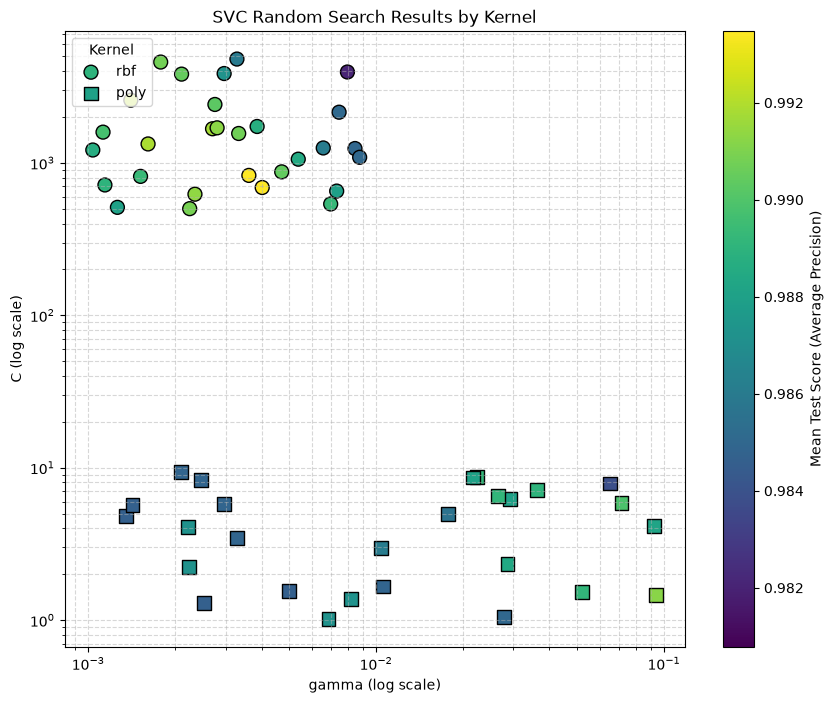

In [43]:
svc_results_rfnd = pd.DataFrame(svc_model.cv_results_)

fig,ax = plt.subplots(figsize=(10,8))
plot_svc_results_nonlinear(svc_results_rfnd, ax=ax)

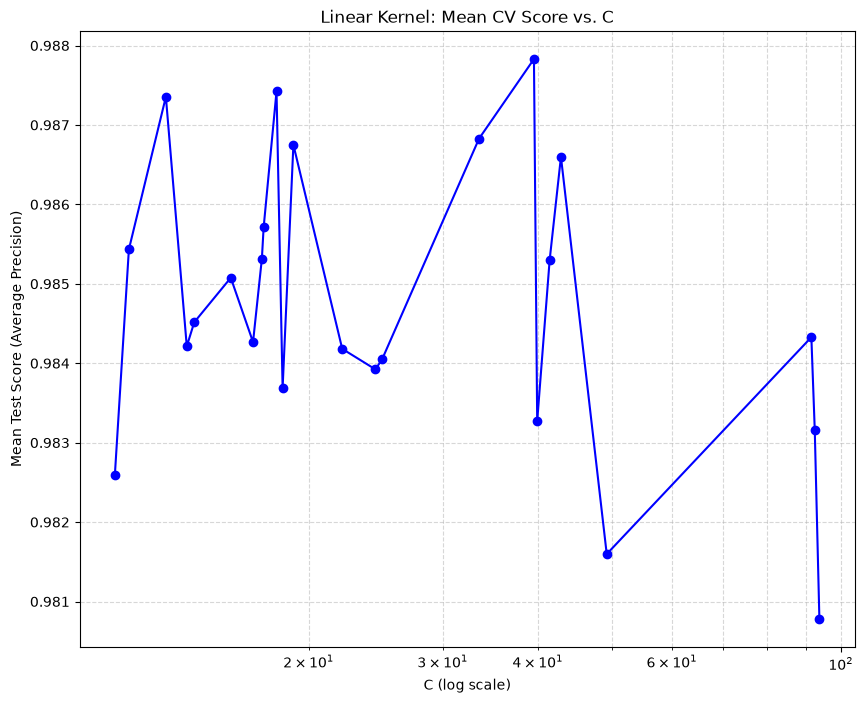

In [44]:
fig,ax = plt.subplots(figsize=(10,8))
plot_svc_results_linear(svc_results_rfnd, ax=ax)

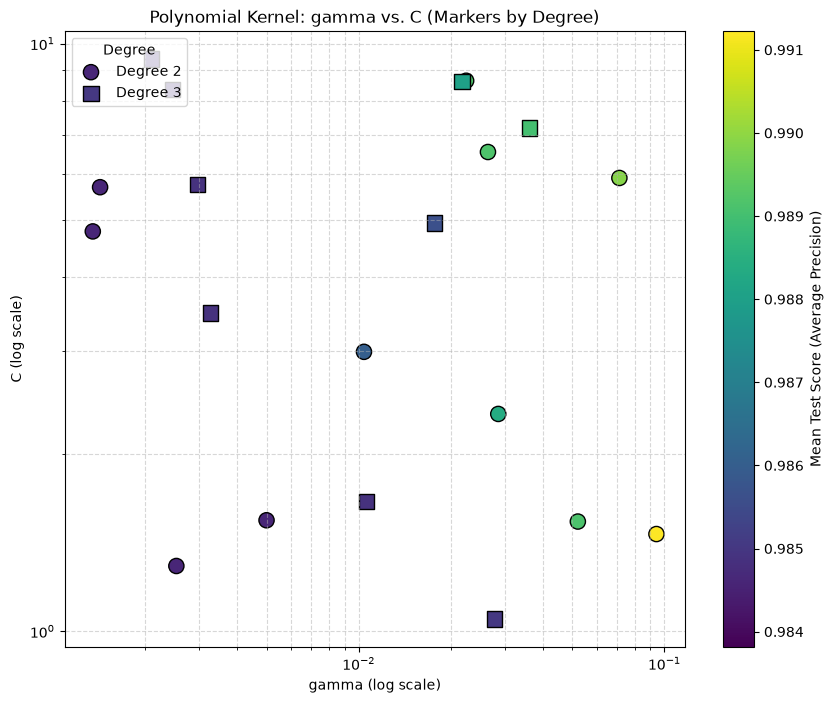

In [45]:
fig,ax = plt.subplots(figsize=(10,8))
plot_svc_results_poly(svc_results_rfnd, ax=ax)

In [46]:
results = (
    "CV Results\n"
    " Best Parameters:\n"
    "  kernel: {}\n"
    "  C: {:.3f}\n"
    "  gamma: {:.3f}\n"
    " Best Validation Score: {:.3%}"
).format(svc_model.best_params_['classifier__kernel'],
         svc_model.best_params_['classifier__C'],
         svc_model.best_params_['classifier__gamma'], 
         svc_model.best_score_)

print(results)

CV Results
 Best Parameters:
  kernel: rbf
  C: 689.130
  gamma: 0.004
 Best Validation Score: 99.348%


### Decision Tree Classifier

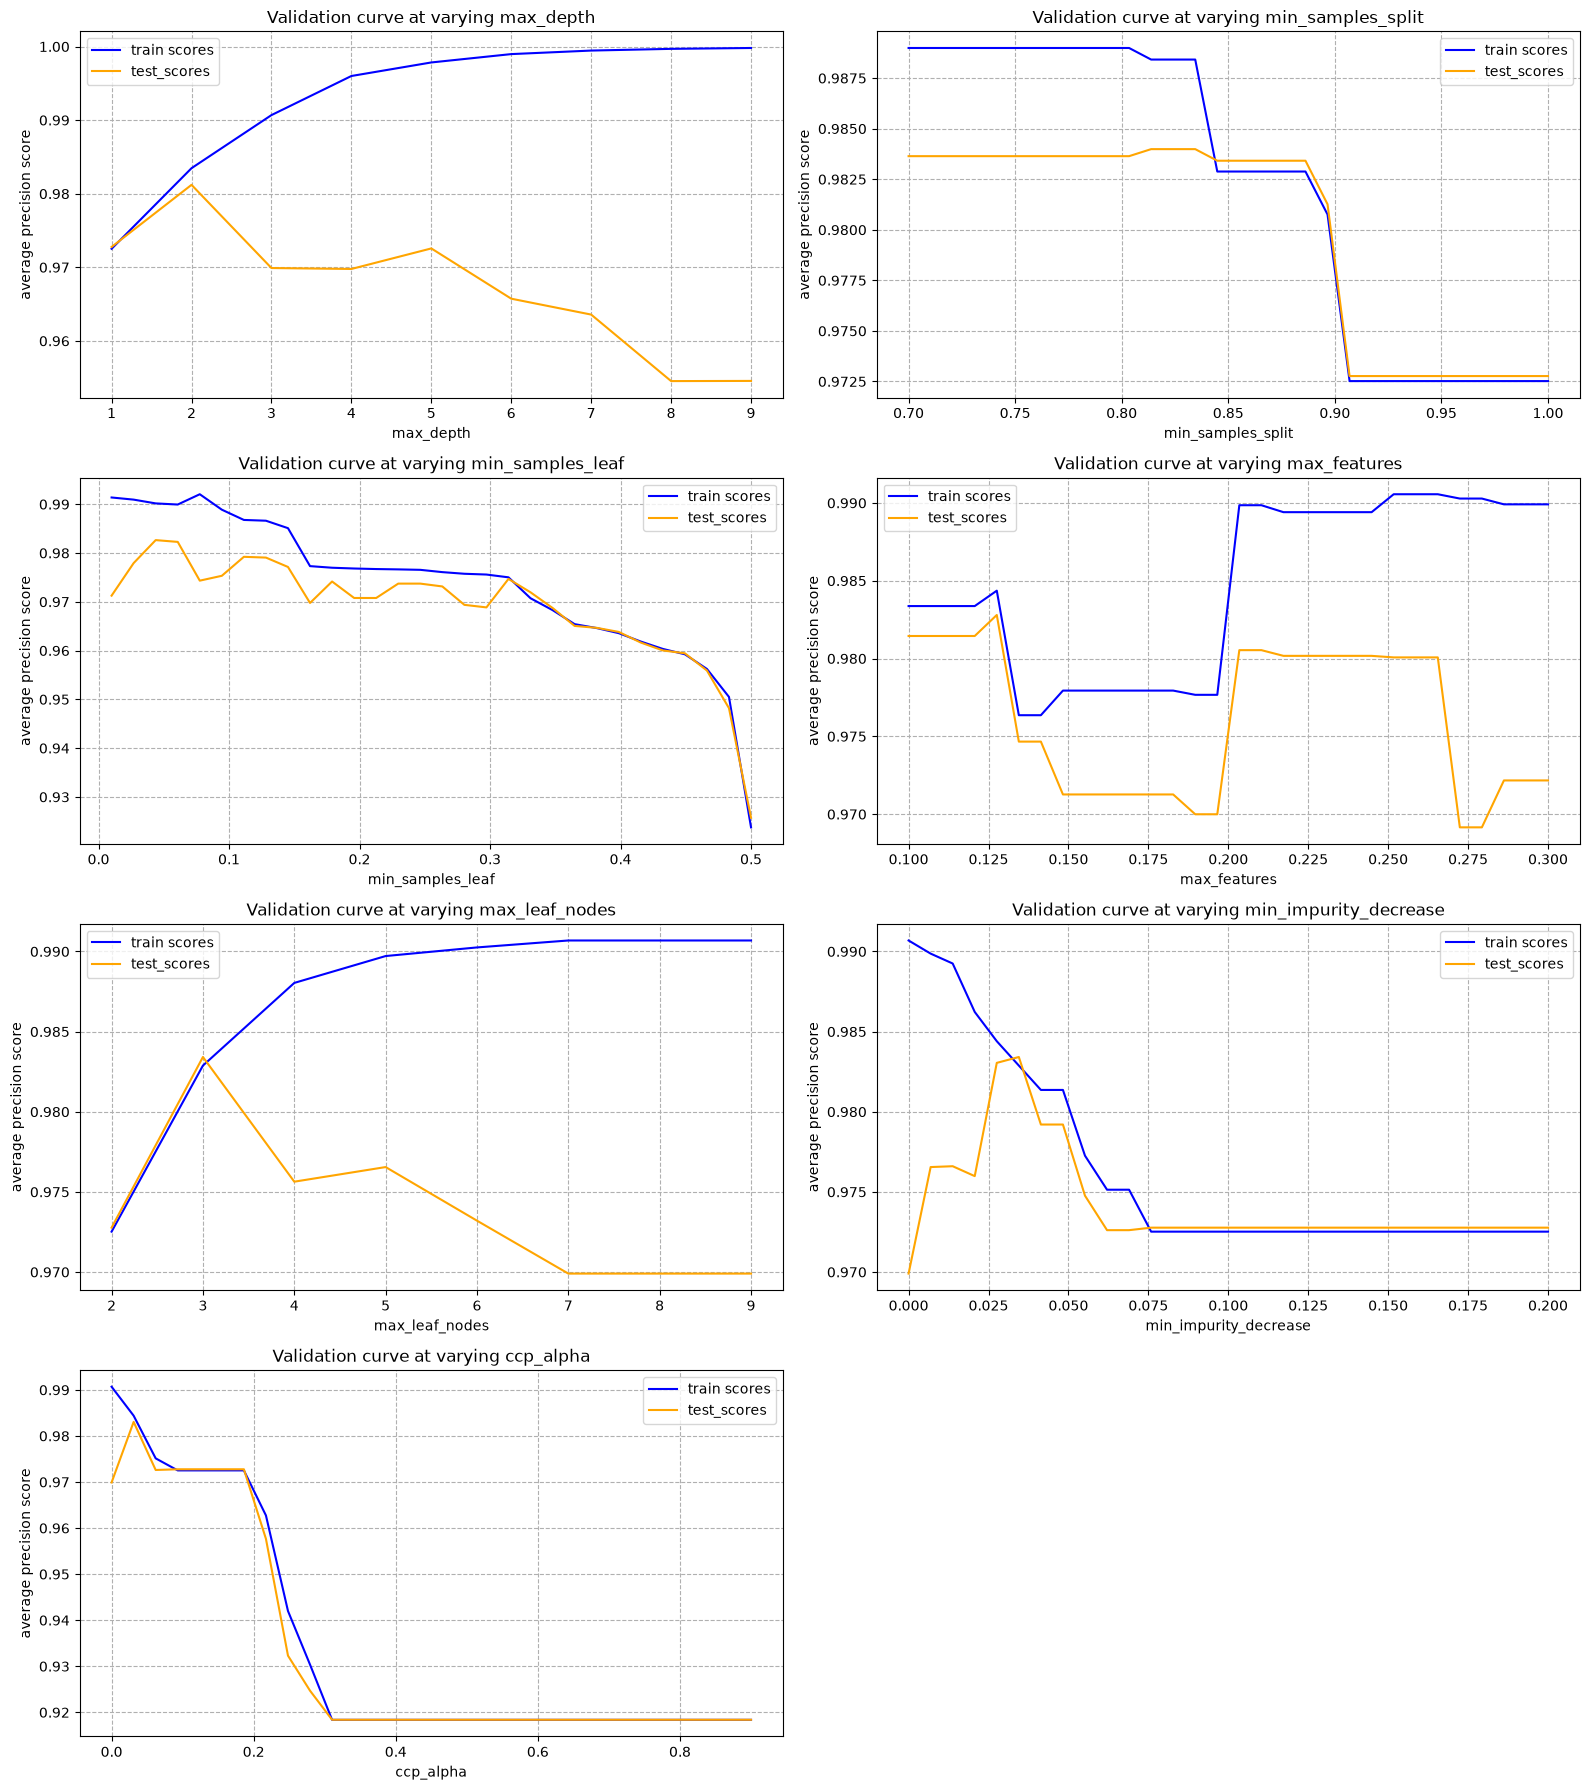

In [47]:
from sklearn.model_selection import validation_curve

def plot_validation_curve(estimator, X, y, param_name, param_range, ax=None):
    if not ax:
        ax = plt.gca()
    
    train_scores, test_scores = validation_curve(
        estimator,
        X, y,
        param_name = param_name,
        param_range = param_range,
        cv = 5,
        scoring = 'average_precision',
        n_jobs=-1
    )
    
    mean_train_scores = np.mean(train_scores, axis=1)
    mean_test_scores = np.mean(test_scores, axis=1)
    ax.plot(param_range, mean_train_scores, color='blue', label='train scores')
    ax.plot(param_range, mean_test_scores, color='orange', label='test_scores')
    ax.set_xlabel(param_name.replace('classifier__', ''))
    ax.set_ylabel('average precision score')
    ax.set_title('Validation curve at varying {}'.format(param_name.replace('classifier__', '')))
    ax.grid(True, which='both', ls='--')
    ax.legend()

tree_model_test = Pipeline([
        ('transform', transformer),
        ('classifier', DecisionTreeClassifier(class_weight='balanced', random_state=random_state, max_depth=3))
    ])

param_grid = {
    'classifier__max_depth': np.arange(1,10,1),
    'classifier__min_samples_split': np.linspace(0.7,1.0,30),
    'classifier__min_samples_leaf': np.linspace(0.01,0.5,30),
    'classifier__max_features': np.linspace(0.1, 0.3, 30),
    'classifier__max_leaf_nodes': np.arange(1,10,1),
    'classifier__min_impurity_decrease': np.linspace(0,0.2,30),
    'classifier__ccp_alpha': np.linspace(0,0.9,30)
}

fig,axs = plt.subplots(4,2,figsize=(16,18))
axs_flat = axs.flatten()
for i, record in enumerate(param_grid.items()):
    name, range_ = record
    plot_validation_curve(tree_model_test, X_train, y_train, name, range_, ax=axs_flat[i])

axs_flat[-1].set_axis_off()
fig.tight_layout()
plt.show()

In [48]:
from sklearn.tree import DecisionTreeClassifier
from scipy.stats import randint

tree_param_grid = {
    'classifier__min_samples_split': uniform(loc=0.7, scale=0.15),
    'classifier__min_samples_leaf': uniform(loc=0, scale=0.1),
    'classifier__max_features': uniform(loc=0.1, scale=0.3),
    'classifier__min_impurity_decrease': uniform(loc=0.01,scale=0.040),
    'classifier__ccp_alpha': uniform(loc=0,scale=0.15)
}

tree_model = RandomizedSearchCV(
    Pipeline([
        ('transform', transformer),
        ('classifier', DecisionTreeClassifier(class_weight='balanced', random_state=random_state, max_depth=3))
    ]),
    tree_param_grid,
    scoring = 'average_precision',
    cv = 5,
    random_state = random_state,
    n_iter = 100,
    n_jobs = -1,
    return_train_score=True
)

tree_model.fit(X_train,y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__ccp_alpha': <scipy.stats....t 0x3a72b0670>, 'classifier__max_features': <scipy.stats....t 0x30faa4050>, 'classifier__min_impurity_decrease': <scipy.stats....t 0x3a72a8210>, 'classifier__min_samples_leaf': <scipy.stats....t 0x30faa4140>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",100
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the whol

#### Results

In [49]:
best_params = tree_model.best_params_
results = "CV Results\n Best Parameters:\n"
for param in tree_param_grid.keys():
    if isinstance(best_params[param], float):
        results += "  {}: {:.3f}\n".format(param.replace("classifier__",""), best_params[param])
    else:
        results += "  {}: {}\n".format(param.replace("classifier__",""), best_params[param])

results += "Best Validation Score: {:.3%}".format(tree_model.best_score_)

print(results)

CV Results
 Best Parameters:
  min_samples_split: 0.712
  min_samples_leaf: 0.023
  max_features: 0.223
  min_impurity_decrease: 0.040
  ccp_alpha: 0.037
Best Validation Score: 98.328%


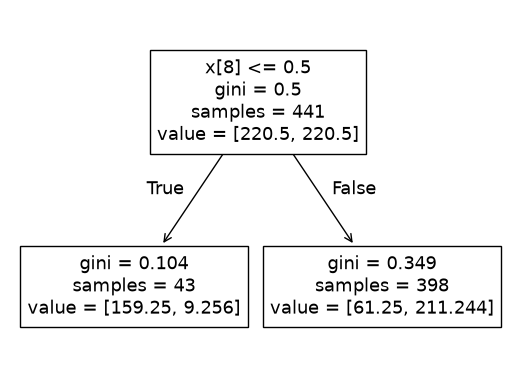

In [50]:
from sklearn import tree

best_tree = tree_model.best_estimator_
clf = best_tree.named_steps['classifier']
tree.plot_tree(clf)
plt.show()

### Comparison

In [51]:
pd.DataFrame(
    {
        'Best Score': [lr_model.best_score_, svc_model.best_score_, tree_model.best_score_]
    },
    index = ['Logistic Regression', 'Support Vector Machines', 'Decision Trees']
)

,Best Score
Logistic Regression,0.990877
Support Vector Machines,0.993477
Decision Trees,0.983281


The SVC classifier will be chosen as the final model. Next section is to tune the threshold of the best estimator based on business requirements.

## Threshold tuning

#### Vanilla predictive model

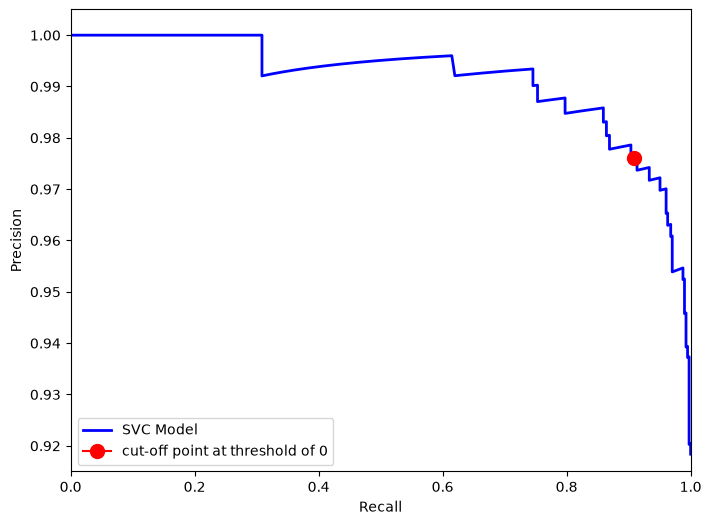

In [52]:
from sklearn.metrics import PrecisionRecallDisplay, precision_recall_curve
from sklearn.model_selection import cross_val_predict

fig, ax = plt.subplots(figsize=(8,6))

y_scores = cross_val_predict(svc_model.best_estimator_, 
                             X_train, 
                             y_train, 
                             cv=5, 
                             method="decision_function")

precisions, recalls, thresholds = precision_recall_curve(y_train, y_scores)

ax.plot(
    recalls,
    precisions,
    color = 'blue',
    ls = '-',
    lw = 2,
    label='SVC Model'
)

# Default threshold
ax.plot(
    recalls[np.argmin(np.abs(thresholds))],
    precisions[np.argmin(np.abs(thresholds))],
    marker="o",
    markersize=10,
    color='red',
    label='cut-off point at threshold of 0'
)

ax.legend()
ax.set_aspect('auto')
ax.set_ylim(0.915,1.005)
ax.set_xlim(0,1)
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')

plt.show()

#### Tuned threshold

Sensitivity analysis for error weights

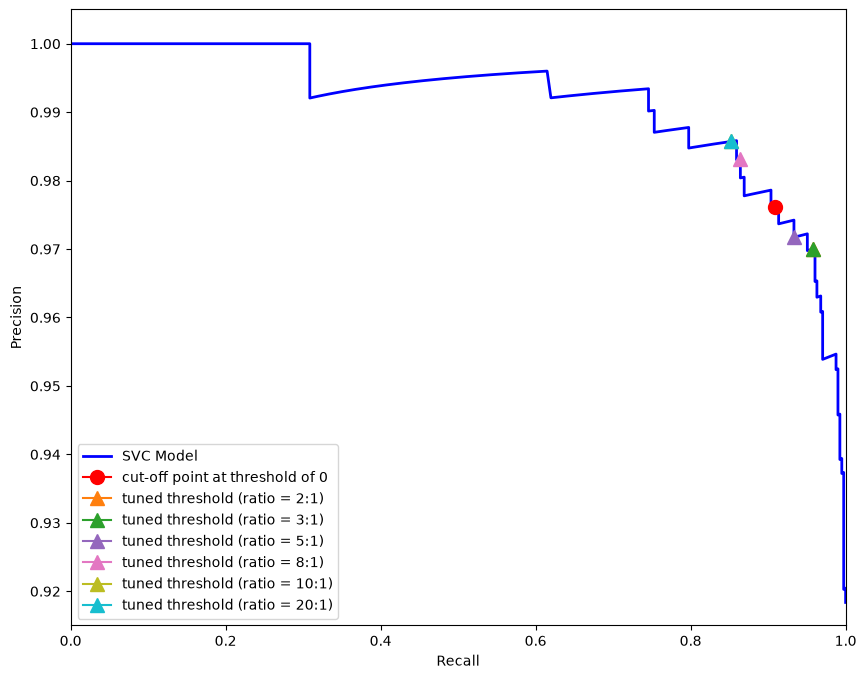

In [53]:
import matplotlib.cm as cm
from sklearn.metrics import make_scorer

fig,ax = plt.subplots(figsize=(10,8))

ax.plot(
    recalls,
    precisions,
    color = 'blue',
    ls = '-',
    lw = 2,
    label='SVC Model'
)

# Default threshold
ax.plot(
    recalls[np.argmin(np.abs(thresholds))],
    precisions[np.argmin(np.abs(thresholds))],
    marker="o",
    markersize=10,
    color='red',
    label='cut-off point at threshold of 0'
)

error_weights = {
    'tuned threshold (ratio = 2:1)': (2,1), 
    'tuned threshold (ratio = 3:1)': (3,1), 
    'tuned threshold (ratio = 5:1)': (5,1), 
    'tuned threshold (ratio = 8:1)': (8,1),
    'tuned threshold (ratio = 10:1)': (10,1), 
    'tuned threshold (ratio = 20:1)': (20,1)
} #(weight_fp, weight_fn)

colors = ["tab:orange", "tab:green", "tab:purple", "tab:pink", "tab:olive", "tab:cyan"]

sensitivity_results = {
    'weights': ['vanilla'],
    'threshold': [0],
    'precision': [precisions[np.argmin(np.abs(thresholds))]],
    'recall': [recalls[np.argmin(np.abs(thresholds))]]
}

for key, val, color in zip(error_weights.keys(), error_weights.values(), colors):
    weights = dict(zip(('weight_fp','weight_fn'),val))
    svc_threshold = TunedThresholdClassifierCV(svc_model.best_estimator_,
                                              scoring = make_scorer(gain_score, **weights),
                                              cv = 5,
                                              random_state=42)
    svc_threshold.fit(X_train,y_train)
    tuned_threshold = svc_threshold.best_threshold_
    idx = np.argmin(np.abs(thresholds - tuned_threshold))
    tuned_precision = precisions[idx]
    tuned_recall = recalls[idx]

    sensitivity_results['weights'].append(val)
    sensitivity_results['threshold'].append(tuned_threshold)
    sensitivity_results['precision'].append(tuned_precision)
    sensitivity_results['recall'].append(tuned_recall)
    
    ax.plot(
        tuned_recall,
        tuned_precision,
        marker="^",
        markersize=10,
        color=color,
        label=key
    )

ax.legend()
ax.set_aspect('auto')
ax.set_ylim(0.915,1.005)
ax.set_xlim(0,1)
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')

plt.show()

In [54]:
pd.DataFrame(sensitivity_results)

,weights,threshold,precision,recall
0,vanilla,0.000000,0.976127,0.908642
1,"(2, 1)",-0.933499,0.970000,0.958025
2,"(3, 1)",-0.933499,0.970000,0.958025
3,"(5, 1)",-0.719711,0.971722,0.933333
4,"(8, 1)",0.848062,0.983146,0.864198
5,"(10, 1)",0.919324,0.985714,0.851852
6,"(20, 1)",0.919324,0.985714,0.851852


**Conclusion.** Settle for `weight_fp=10` and `weight_fn=1`

### Final Model - SVC

In [59]:
weights = {'weight_fp': 10, 'weight_fn': 1}
scoring = make_scorer(gain_score, **weights)
svc_model_tuned = TunedThresholdClassifierCV(svc_model.best_estimator_,
                                             scoring=scoring,
                                             cv=5,
                                             random_state=random_state)
svc_model_tuned.fit(X_train, y_train)

,"estimator estimator: estimator instanceThe classifier, fitted or not, for which we want to optimizethe decision threshold used during `predict`.",Pipeline(step...m_state=42))])
,"scoring scoring: str or callable, default=""balanced_accuracy""The objective metric to be optimized. Can be one of:- str: string associated to a scoring function for binary classification, see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.","make_scorer(g..., weight_fn=1)"
,"cv cv: int, float, cross-validation generator, iterable or ""prefit"", default=NoneDetermines the cross-validation splitting strategy to train classifier.Possible inputs for cv are:* `None`, to use the default 5-fold stratified K-fold cross validation;* An integer number, to specify the number of folds in a stratified k-fold;* A float number, to specify a single shuffle split. The floating number should be in (0, 1) and represent the size of the validation set;* An object to be used as a cross-validation generator;* An iterable yielding train, test splits;* `""prefit""`, to bypass the cross-validation.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... warning:: Using `cv=""prefit""` and passing the same dataset for fitting `estimator` and tuning the cut-off point is subject to undesired overfitting. You can refer to :ref:`TunedThresholdClassifierCV_no_cv` for an example. This option should only be used when the set used to fit `estimator` is different from the one used to tune the cut-off point (by calling :meth:`TunedThresholdClassifierCV.fit`).",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of cross-validation when `cv` is a float.See :term:`Glossary <random_state>`.",42
,"response_method response_method: {""auto"", ""decision_function"", ""predict_proba""}, default=""auto""Methods by the classifier `estimator` corresponding to thedecision function for which we want to find a threshold. It can be:* if `""auto""`, it will try to invoke, for each classifier, `""predict_proba""` or `""decision_function""` in that order.* otherwise, one of `""predict_proba""` or `""decision_function""`. If the method is not implemented by the classifier, it will raise an error.",'auto'
,"thresholds thresholds: int or array-like, default=100The number of decision threshold to use when discretizing the output of theclassifier `method`. Pass an array-like to manually specify the thresholdsto use.",100
,"refit refit: bool, default=TrueWhether or not to refit the classifier on the entire training set oncethe decision threshold has been found.Note that forcing `refit=False` on cross-validation having morethan a single split will raise an error. Similarly, `refit=True` inconjunction with `cv=""prefit""` will raise an error.",True
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. When `cv` represents across-validation strategy, the fitting and scoring on each data splitis done in parallel. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"store_cv_results store_cv_results: bool, default=FalseWhether to store all scores and thresholds computed during the cross-validationprocess.",False
Name,Type,Value
"best_score_ best_score_: float or NoneThe optimal score of the objective metric, evaluated at `best_threshold_`.",float64,-21.93


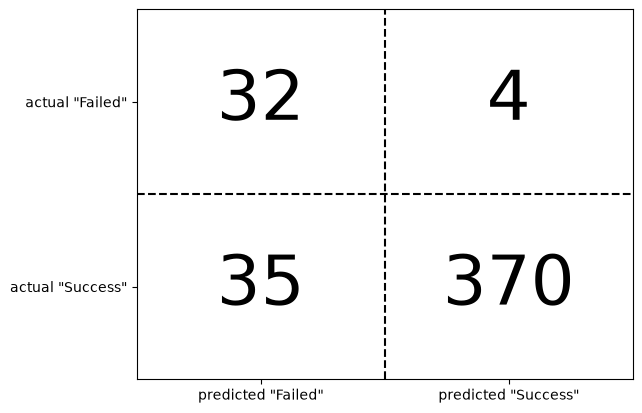

In [60]:
binary_confusion_plot(confusion_matrix(y_train, svc_model.predict(X_train)), 
                      positive_class='Success', 
                      negative_class='Failed')

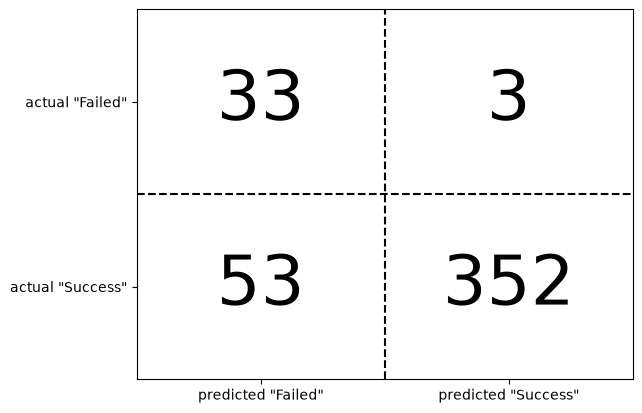

In [61]:
binary_confusion_plot(confusion_matrix(y_train, svc_model_tuned.predict(X_train)), 
                      positive_class='Success', 
                      negative_class='Failed')

### Performance on Test Set

In [68]:
from sklearn.metrics import precision_score, recall_score

svc_pred = svc_model_tuned.predict(X_test)
svc_test_score = scoring(svc_model_tuned, X_test, y_test)
svc_test_precision = precision_score(y_test, svc_pred)
svc_test_recall = recall_score(y_test, svc_pred)
print('SVC Test Score: {:.3f}'.format(svc_test_score))
print('Precision Score: {:.3%}'.format(svc_test_precision))
print('Recall Score: {:.3%}'.format(svc_test_recall))

SVC Test Score: -44.000
Precision Score: 96.703%
Recall Score: 86.275%


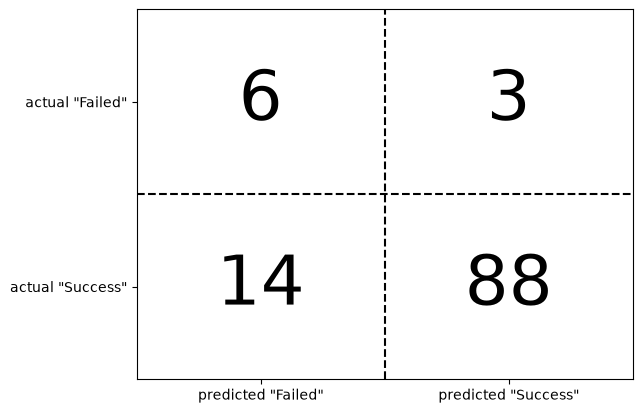

In [70]:
lr_confusion = confusion_matrix(y_test, svc_pred)
binary_confusion_plot(lr_confusion, positive_class='Success', negative_class='Failed')